# Seismic tomography using PI-INN

In [1]:
import torch, torchvision
import torch.nn as nn
import torch.distributions as distributions
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import h5py
import time
import os

from INN import RealNVP
from tqdm import tqdm
from neural_network import fully_connected
from torch.autograd import Variable
from torch.utils.data import TensorDataset
from mpl_toolkits.axes_grid1 import make_axes_locatable
from torch.optim import lr_scheduler
from sklearn.neighbors import KernelDensity
from scipy.stats import gaussian_kde


torch.manual_seed(2022)
torch.set_default_dtype(torch.float64)

class Hyperparameters():
    def __init__(self, base_dim, weight_norm, res_blocks, skip, coupling_bn):
        self.base_dim = base_dim
        self.weight_norm = weight_norm
        self.res_blocks = res_blocks
        self.skip = skip
        self.coupling_bn = coupling_bn
        

## Load datasets

In [2]:
device = torch.device("cuda:0")
model_name = 'Seismic_Tomography_with_grad'

# params for INN
batch_size = 500
hps = Hyperparameters(
    base_dim=256,
    res_blocks=0,
    skip=False,
    weight_norm=False, 
    coupling_bn=False)
        
# optimizer
lr = 1e-3
momentum = 0.9
decay = 0.99

# N-dimensions
ndim_x = 20
ndim_c_u = 30
ndim_z = 10
ndim_x_pad = ndim_c_u + ndim_z - ndim_x

add_pad_noise = 1

T_train = np.load('../data/generate_t_prior_2.npy')
Z_train = np.load('../data/generate_z_prior_2.npy')
Z_mean = Z_train.mean(axis = 0)
Z_std = Z_train.std(axis = 0)
V_train = np.exp(4*np.load('../data/generate_v_prior_2.npy')-2).squeeze(1)

T_test = np.load('../data/TravelTime_112.npy')
Z_test = np.load('../data/latent_means_112.npy')
V_test= np.exp(4*np.load('../data/Fields_112.npy')-2)

## Construct datasets

In [ ]:
def get_boundary_indices(N_discrete, step=1):

    corner_indices = {
        (0, 0): 0,
        (0, N_discrete-1): N_discrete - 1,
        (N_discrete-1, 0): (N_discrete - 1) * N_discrete,
        (N_discrete-1, N_discrete-1): N_discrete * N_discrete - 1
    }

    bottom_indices = torch.arange(0, N_discrete)  # z = zmin
    top_indices = torch.arange((N_discrete - 1) * N_discrete, N_discrete * N_discrete)  # z = zmax
    left_indices = torch.arange(0, N_discrete * N_discrete, N_discrete)  # x = xmin
    right_indices = torch.arange(N_discrete - 1, N_discrete * N_discrete, N_discrete)  # x = xmax

    selected_bottom_indices = bottom_indices[::step].tolist() + [bottom_indices[-1].item()]
    selected_top_indices = top_indices[::step].tolist() + [top_indices[-1].item()]
    selected_left_indices = left_indices[::step].tolist() + [left_indices[-1].item()]
    selected_right_indices = right_indices[::step].tolist() + [right_indices[-1].item()]

    selected_bottom_indices = list(set(selected_bottom_indices) - set(corner_indices.values()))
    selected_top_indices = list(set(selected_top_indices) - set(corner_indices.values()))
    selected_left_indices = list(set(selected_left_indices) - set(corner_indices.values()))
    selected_right_indices = list(set(selected_right_indices) - set(corner_indices.values()))

    boundary_indices = sorted( selected_top_indices +
                              selected_left_indices + selected_right_indices +
                              list(corner_indices.values()))

    boundary_2d_indices = [(i // N_discrete, i % N_discrete) for i in boundary_indices]

    return boundary_indices

N_discrete = 112
zmin = -11.2; zmax = 11.2;
xmin = -11.2; xmax = 11.2;
h = (xmax - xmin) / (N_discrete)

# Meshgrid points
# .flip(dims=[0])
z_range = torch.arange(zmin, zmax, h).flip(dims=[0])
x_range = torch.arange(xmin, xmax, h)
zz, xx = torch.meshgrid(z_range, x_range, indexing='ij')
X_f = torch.concat([xx.reshape(-1, 1), zz.reshape(-1, 1)], dim=1).to(device)
# collocation points
x_f = Variable(X_f[:, 0:1], requires_grad=True).to(device)
z_f = Variable(X_f[:, 1:], requires_grad=True).to(device)


boundary_indices = get_boundary_indices(N_discrete, step=7)
boundary_2d_indices = [(i // N_discrete, i % N_discrete) for i in boundary_indices]

# source points: (0, 0)
sz = 0
sx = 0

# source index
tolx = 1e-6
tolz = 1e-6
sids = int(torch.where((torch.abs(X_f[:, 1] - sz) < tolz) & (torch.abs(X_f[:, 0] - sx) < tolx))[0][0])
sz_idx = sids // N_discrete
sx_idx = sids % N_discrete



print("==>Input dim:")
print("ndim_x:", ndim_x)
print("ndim_x_pad:", ndim_x_pad)
print("==>Output dim:")
print("ndim_c_u:", ndim_c_u)
print("ndim_z:", ndim_z)
print("==> Input Total Dim:", ndim_x + ndim_x_pad)
print("==> Output Total Dim:", ndim_c_u + ndim_z)


# input data

x_train = torch.from_numpy(Z_train).float()
x_test = torch.from_numpy(Z_test).float()

# velocity and traveltime data
v_train = torch.from_numpy(V_train).float().reshape(-1, N_discrete, N_discrete)
v_test = torch.from_numpy(V_test).float().reshape(-1, N_discrete, N_discrete)
t_train = torch.from_numpy(T_train).float().reshape(-1, N_discrete, N_discrete)
t_test = torch.from_numpy(T_test).float().reshape(-1, N_discrete, N_discrete)

# construct data loader
train_loader = torch.utils.data.DataLoader(TensorDataset(x_train, v_train, t_train), batch_size=batch_size, 
                                           shuffle=True, drop_last=True)
test_loader = torch.utils.data.DataLoader(TensorDataset(x_test, v_test, t_test), batch_size=batch_size, 
                                           shuffle=True, drop_last=True)

==>Input dim:
ndim_x: 20
ndim_x_pad: 20
==>Output dim:
ndim_c_u: 30
ndim_z: 10
==> Input Total Dim: 40
==> Output Total Dim: 40


## Network architecture

In [4]:
class Uniform:
    """
    Approximate 1-d uniform distribution with smoothing
    """
    def __init__(self, lb, ub):
        self.lb = lb
        self.ub = ub
        self.prob_in = 1 / (ub - lb)
        
    def sample(self, sample_size):
        return self.lb + (self.ub - self.lb) * torch.rand(sample_size)
    
    def log_prob(self, x):
        epsilon = 0.1
        tol = 1e-4
        
        px = 1/(2*(self.ub-self.lb)) * torch.tanh((x+self.ub) / epsilon) + 1/(2*(self.ub-self.lb)) * torch.tanh((-x-self.lb) / epsilon) + tol
        log_px = torch.log(px)
        return log_px

in_out_dim = ndim_x + ndim_x_pad
latent = distributions.Normal(
    torch.tensor(0.).to(device), torch.tensor(1.1).to(device))
prior_kl_z = distributions.Normal(
    torch.tensor(Z_mean).to(device), torch.tensor(Z_std*1.1).to(device))

xpad = distributions.Normal(
    torch.tensor(0.).to(device), torch.tensor(add_pad_noise*1.1).to(device))

# INN and NB-Net
INN = RealNVP(in_out_dim, hps=hps).to(device)
NB_Net = fully_connected(units=128, layers=8, in_dim=2, out_dim=ndim_c_u, activation='Tanh').to(device)

# xavier initialziations
params_INN = [p for p in INN.parameters() if p.requires_grad]
for p in params_INN:
    if p.ndimension() == 1:
        p.data =  0.01*nn.init.xavier_normal_(p.data.unsqueeze(-1)).squeeze(-1).to(device)
    else:
        p.data =  0.01*nn.init.xavier_normal_(p.data).to(device)
        
# combined params
params_basis = [p for p in NB_Net.parameters() if p.requires_grad]
combined_params = params_INN + params_basis

optimizer = optim.AdamW(combined_params, lr=lr, betas=(momentum, decay), eps=1e-7)

# learning rate decay
scheduler = lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.95, verbose=False)

## Loss functions

In [ ]:
def equation_loss(v, tau, tau_x, tau_z, T0, T0_x, T0_z):
    res = (T0 * tau_x + tau * T0_x) ** 2 + (T0 * tau_z + tau * T0_z) ** 2 - 1.0 / v ** 2
    return torch.mean(res ** 2)

def source_loss(tau):
    source_tau = tau[:, sz_idx, sx_idx]
    return torch.mean((source_tau - 1)** 2,dim=0)

def log_Px(out_x_xpad, log_det_J):
    out_x_x = out_x_xpad[:, 0:ndim_x]

    out_x_pad = out_x_xpad[:, -ndim_x_pad:]
#     print( out_x_grad.shape)
    
    log_p_x = torch.sum(prior_kl_z.log_prob(out_x_x), dim=1)

    log_p_pad = torch.sum(xpad.log_prob(out_x_pad), dim=1)
    return log_p_x + log_p_pad + log_det_J
    
def independence_loss(out_x, log_det_J, out_x_star, log_det_J_star, normal_dist):
    
    log_px = log_Px(out_x, log_det_J)
    log_px_star = log_Px(out_x_star, log_det_J_star)
    
    # 计算原始损失
    loss = torch.square(log_px - log_px_star - normal_dist)
    
    # 对异常位置的损失进行裁剪
    loss = torch.clamp(loss, max=1e4)
    
    
    return torch.mean(loss,dim=0)

def rev_loss(x, out_t, t_star, z_star):
    T_obs = t_star
    tau_obs = T_obs.to(device) / T0
    tau_obs[:, sz_idx, sx_idx] = 1
    tau_obs= tau_obs.reshape(batch_size, N_discrete ** 2)
    
    tau_obs = tau_obs[:,boundary_indices]  # (m, d)
    out_t_obs = out_t[boundary_indices].T  # (n, d)

    out_t_cov = out_t_obs @ out_t_obs.T  # (n, n)

    cross_cov = out_t_obs @ tau_obs.T   # (m, n)
    c_infer = torch.linalg.solve(out_t_cov, cross_cov).T  # (m, n)


    cz_infer = torch.concat([c_infer, z_star], dim=1)

    
    x_xpad = INN(cz_infer, reverse=True)[0]
    x_pred = x_xpad[:, 0:ndim_x]
    return torch.mean(torch.norm(x[:, 0:ndim_x] - x_pred, dim=1) / torch.norm(x[:, 0:ndim_x], dim=1) )

def forwardfit_loss(tau,T0,t_star):
    T_obs = t_star.reshape(batch_size, N_discrete ** 2).T[boundary_indices]
    T_fit = (T0*tau).reshape(batch_size, N_discrete ** 2).T[boundary_indices]
    return torch.mean(torch.norm(T_obs - T_fit, dim=1) / torch.norm(T_obs, dim=1))

def calculate_T0(v_train, sx, sz, v_source):
    dist_matrix = torch.sqrt((zz - sz)**2 + (xx - sx)**2).reshape(N_discrete, N_discrete).to(device)

    T0 = dist_matrix.unsqueeze(0) / v_source.unsqueeze(1).unsqueeze(2)  # (batch_size, N_discrete, N_discrete)
    
    T0_x_data = (xx.to(device) - sx) / (T0 * v_source.unsqueeze(1).unsqueeze(2)**2)
    T0_z_data = (zz.to(device) - sz) / (T0 * v_source.unsqueeze(1).unsqueeze(2)**2)

    T0_x = T0_x_data * (T0 != 0)
    T0_z = T0_z_data * (T0 != 0)
    
    return T0, T0_x, T0_z

In [6]:
# INN = torch.load('./models/INN_copy1.pt')
# NB_Net = torch.load('./models/NB_Net_copy1.pt')

In [7]:
max_epoch = 1000
epoch = 0

weight_ind = 1.
weight_rev = 10
weight_fit = 5
best_val_loss = 1e+5

load_model = True

if (load_model==False):

    start_time = time.time()

    while epoch < max_epoch:
        epoch += 1
        print('Epoch %d:' % epoch)

        INN.train()
        running_loss = 0.
        running_rev = 0.
        running_ind = 0.
        running_fit = 0.

        #========================================================================= 
        #============================Training Stage=============================== 
        #=========================================================================

        for batch_idx, (x, v, t) in enumerate(train_loader):

            batch_idx += 1
            x = x.to(device).double()
            if ndim_x_pad>0:
                x = torch.cat((x, add_pad_noise*torch.randn(batch_size, ndim_x_pad).to(device)), dim=1)
            v_star = v.float().to(device)
            v_source = v_star [:, sz_idx, sx_idx]
            t_star = t.float().to(device)
            z_star = torch.randn(len(x), ndim_z).to(device)
            T0, T0_x, T0_z = calculate_T0(v_star,sx,sz, v_source)
            
            # predict traveltime T = tau x T0
            out_yz = INN(x)[0]
            out_c, out_z = out_yz[:, 0:ndim_c_u], out_yz[:, -ndim_z:]
            out_t = NB_Net(x_f, z_f)
            
            tau = (out_c @ out_t.T).reshape(batch_size, N_discrete, N_discrete)

            # compute loss terms
            loss_fit = forwardfit_loss(tau,T0,t_star)
            
            # independece loss term
            yz = torch.cat((out_yz[:, 0:ndim_c_u], z_star), dim=1)
            out_x_xpad, log_det_J = INN(out_yz, reverse=True)
            out_x_xpad_star, log_det_J_star = INN(yz, reverse=True)
            normal_dist = torch.sum(latent.log_prob(out_z) - latent.log_prob(z_star), dim=1)
            loss_ind = independence_loss(out_x_xpad, log_det_J, out_x_xpad_star, log_det_J_star, normal_dist)

            # reverse loss term (just for check)
            loss_rev = rev_loss(x, out_t, t_star, z_star)

            # total loss functions
            loss =  weight_ind * loss_ind + weight_rev * loss_rev + weight_fit * loss_fit

            running_loss += loss.item()
            running_ind += loss_ind.item()
            running_rev += loss_rev.item()
            running_fit += loss_fit.item()

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()


        mean_loss = running_loss / batch_idx
        mean_ind = running_ind / batch_idx
        mean_rev = running_rev / batch_idx
        mean_fit = running_fit / batch_idx

        print('===> Average train loss: %.6f,\t ind loss: %.6f,\t rev loss: %.6f, fit loss: %.6f' % 
              ( mean_loss, mean_ind, mean_rev,mean_fit))

        INN.eval()
        running_loss = 0.
        running_rev = 0.
        running_ind = 0.
        running_fit = 0.

        #========================================================================= 
        #============================Validation Stage============================= 
        #=========================================================================

        for batch_idx, (x, v, t) in enumerate(test_loader):

            batch_idx += 1
            x = x.to(device).double()
            if ndim_x_pad>0:
                x = torch.cat((x, add_pad_noise*torch.randn(batch_size, ndim_x_pad).to(device)), dim=1)
            v_star = v.float().to(device)
            v_source = v_star [:, sz_idx, sx_idx]
            t_star = t.float().to(device)
            z_star = torch.randn(len(x), ndim_z).to(device)
            T0, T0_x, T0_z = calculate_T0(v_star,sx,sz, v_source)

            # predict traveltime T = tau x T0
            
            out_yz = INN(x)[0]
            out_c, out_z = out_yz[:, 0:ndim_c_u], out_yz[:, -ndim_z:]
            out_t = NB_Net(x_f, z_f)
            
            tau = (out_c @ out_t.T).reshape(batch_size, N_discrete, N_discrete)

            # compute loss terms
            loss_fit = forwardfit_loss(tau,T0,t_star)
            
            # independece loss term
            yz = torch.cat((out_yz[:, 0:ndim_c_u], z_star), dim=1)
            out_x_xpad, log_det_J = INN(out_yz, reverse=True)
            out_x_xpad_star, log_det_J_star = INN(yz, reverse=True)
            normal_dist = torch.sum(latent.log_prob(out_z) - latent.log_prob(z_star), dim=1)
            loss_ind = independence_loss(out_x_xpad, log_det_J, out_x_xpad_star, log_det_J_star, normal_dist)

            # reverse loss term (just for check)
            loss_rev = rev_loss(x, out_t, t_star, z_star)

            # total loss functions
            loss =  weight_ind * loss_ind + weight_rev * loss_rev + weight_fit * loss_fit

            running_loss += loss.item()
            running_ind += loss_ind.item()
            running_rev += loss_rev.item()
            running_fit += loss_fit.item()
            

        mean_loss = running_loss / batch_idx
        mean_ind = running_ind / batch_idx
        mean_rev = running_rev / batch_idx
        mean_fit = running_fit / batch_idx

        print('===> Average test loss: %.6f,\t ind loss: %.6f,\t rev loss: %.6f, fit loss: %.6f' % 
              (mean_loss,mean_ind, mean_rev,mean_fit))

        if best_val_loss > mean_loss:
            best_val_loss = mean_loss
            torch.save(INN, './models/INN_copy3.pt')
            torch.save(NB_Net, './models/NB_Net_copy3.pt') 

        scheduler.step()
    print('Time elapsed:', time.time() - start_time)
else:
    INN = torch.load('./models/INN_copy3.pt')
    NB_Net = torch.load('./models/NB_Net_copy3.pt')


In [15]:
import VAE

# INN = torch.load('./models/INN_copy3.pt',map_location =device)
# NB_Net = torch.load('./models/NB_Net_copy3.pt',map_location =device)

vae = VAE.model.to(device)



In [16]:
test_size = v_test.shape[0]
v_test = v_test.float().to(device)
v_source = v_test [:, sz_idx, sx_idx]
T0, T0_x, T0_z = calculate_T0(v_test,sx,sz, v_source)
T_obs = t_test
tau_obs = T_obs.to(device) / T0
tau_obs[:, sz_idx, sx_idx] = 1
tau_obs= tau_obs.reshape(test_size, N_discrete ** 2)
tau_obs = tau_obs.T[boundary_indices].T
out_t = NB_Net(x_f, z_f)

out_t_obs =  out_t[boundary_indices]
out_t_pinverse = torch.pinverse(out_t_obs)
c_infer = tau_obs @ out_t_pinverse.T
z_star = torch.randn(test_size, ndim_z).to(device)
cz_infer = torch.concat([c_infer, z_star], dim=1)
x_xpad = INN(cz_infer, reverse=True)[0]
x_pred = x_xpad[:, 0:ndim_x]

In [17]:
x_pred0 = x_pred.cpu().detach().numpy()
x_test0 = x_test.double().detach().numpy()

np.linalg.norm(x_test0-x_pred0)/np.linalg.norm(x_test0)

0.3808967891638813

In [ ]:
x_pred = x_pred.cpu().detach().numpy()
x_test0 = x_test.double().detach().numpy()
batch_size = 1000 
num_samples = x_test.shape[0] # 样本总数
fields_pred = []
fields_pred_var = []
with torch.no_grad():
    for i in range(0, num_samples, batch_size):
        x_pred_batch = torch.tensor(x_pred[i:i + batch_size]).to(device)
        fields_pred_batch,fields_pred_var_batch = vae.decode(x_pred_batch) 

        fields_pred.append(fields_pred_batch.detach().cpu().numpy())
        fields_pred_var.append(fields_pred_var_batch.detach().cpu().numpy())
        torch.cuda.empty_cache()


fields_pred = np.concatenate(fields_pred, axis=0)
fields_pred_var = np.concatenate(fields_pred_var, axis=0)
fields_pred_std = np.sqrt(fields_pred_var)

AttributeError: 'numpy.ndarray' object has no attribute 'cpu'

In [ ]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

fields_true = np.load("../data/Fields_112.npy")
fields_pred1 = fields_pred.squeeze(1)

def calculate_ssim(img1, img2,data_range=None):
    ssim_value, _ = ssim(img1, img2, full=True,data_range=data_range)
    return ssim_value

def calculate_snr(img1, img2):
    signal_power = np.mean(img1**2)  
    noise_power = np.mean((img1 - img2)**2) 
    snr_value = 10 * np.log10(signal_power / noise_power)  
    return snr_value


ssim_value_list = []
snr_value_list = []

for i in range(40):
    image1 = fields_true[100*i]
    image2 = fields_pred1[100*i]

    ssim_value = calculate_ssim(image1, image2,data_range=1.0)
    snr_value = calculate_snr(image1, image2)
    ssim_value_list.append(ssim_value)
    snr_value_list.append(snr_value)

ssim_mean = np.mean(ssim_value_list,axis=0)
snr_mean = np.mean(snr_value_list,axis=0)

print("ssim_mean:",ssim_mean,'\n',"snr_mean:",snr_mean)

ssim_mean: 0.6431244300090351 
 snr_mean: 12.354060732261834


In [ ]:
N_test=5000 

k=1000

x_sample = x_test[k,:].cpu().numpy()
v_sample = v_test[k,:].cpu().numpy()
t_sample = t_test[k,:].cpu().numpy()

x = torch.tensor(np.tile(x_sample, (N_test, 1))).float().to(device)

v_star = torch.tensor(np.tile(v_sample[None,:,:], (N_test,1, 1))).float().to(device)

t_star = torch.tensor(np.tile(t_sample, (N_test,1, 1))).float().to(device)
t_star = t_star 

def test_rev(x, out_t, tau_obs):

    out_t_cov = out_t @ out_t.T  # (n, n)

    cross_cov = out_t @ tau_obs.T   # (m, n)
    c_infer = torch.linalg.solve(out_t_cov, cross_cov).T  # (m, n)

    z_star = torch.randn(len(x), ndim_z).to(device)
    cz_infer = torch.concat([c_infer, z_star], dim=1)
    
    x_xpad = INN(cz_infer, reverse=True)[0]
    x_pred = x_xpad[:, 0:ndim_x]
    return torch.mean(torch.norm(x[:, 0:ndim_x] - x_pred, dim=1) / torch.norm(x[:, 0:ndim_x], dim=1)) , x_pred

running_rev = 0.


#=========================================================================
#============================Validation Stage=============================
#=========================================================================
# for batch_idx, (x, v, t) in enumerate(test_loader):
if ndim_x_pad>0:
    x = torch.cat((x, add_pad_noise*torch.randn(N_test, ndim_x_pad).to(device)), dim=1)
    
v_source = v_star [:, sz_idx, sx_idx]
    
T0, T0_x, T0_z = calculate_T0(v_star,sx,sz, v_source)

tau_obs = t_star/ T0
tau_obs[:, sz_idx, sx_idx] = 1

# predict traveltime T = tau x T0
out_yz = INN(x)[0]
out_c, out_z = out_yz[:, 0:ndim_c_u], out_yz[:, -ndim_z:]
out_t = NB_Net(x_f, z_f)

tau_obs = tau_obs.reshape(N_test,-1)

tau_obs = tau_obs[:,boundary_indices]

out_t = out_t[boundary_indices].T

loss_rev , x_pred= test_rev(x, out_t, tau_obs)

print('===> Average  rev loss: %.6f' %  ( loss_rev))

x_pred = x_pred.cpu().detach().numpy()

===> Average  rev loss: 0.163961


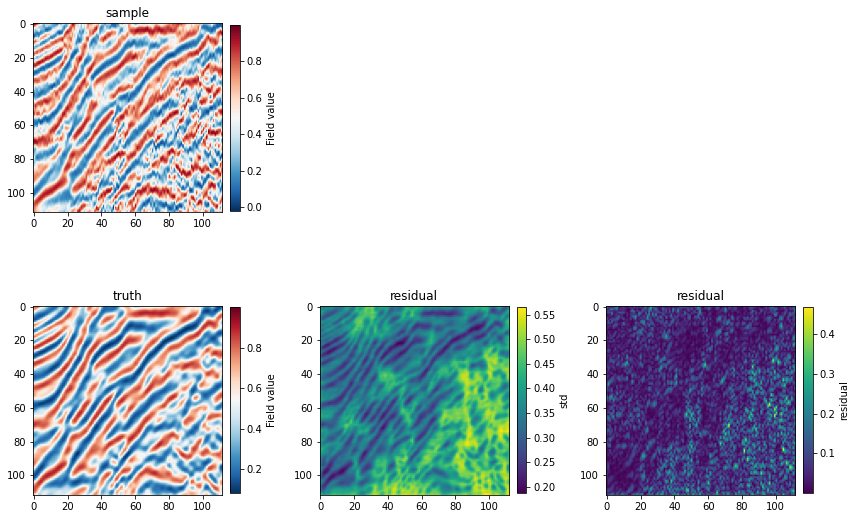

In [22]:
F_true = np.load('../data/Fields_112.npy')[k]
F_sample_mean = fields_pred.mean(axis=0).squeeze(0)
F_sample_var = fields_var.mean(axis=0).squeeze(0)
F_sample_std = np.sqrt(F_sample_var)
F_sample_error = np.abs(F_sample_mean-F_true)


fig, axs = plt.subplots(2, 3, figsize=(12, 8))
pad = 0.04
fraction=0.045

vmin = min(F_true.min(), F_sample_mean.min())
vmax = max(F_true.max(), F_sample_mean.max())

# axs[0] = fig.add_subplot(1, 3, 1)
im1 = axs[0,0].imshow(F_true, cmap= 'RdBu_r', vmin=vmin, vmax=vmax)
fig.colorbar(im1, ax=axs[0,0], label='Field value', pad=pad ,fraction=fraction)
axs[0,0].set_title('sample')

fig.delaxes(fig.add_subplot(axs[0, 1]))
fig.delaxes(fig.add_subplot(axs[0, 2]))

# axs[1] = fig.add_subplot(1, 3, 2)
im2 = axs[1,0].imshow(F_sample_mean, cmap= 'RdBu_r', vmax=vmax)
fig.colorbar(im2, ax=axs[1,0], label='Field value', pad=pad ,fraction=fraction)
axs[1,0].set_title('truth')

# axs[2] = fig.add_subplot(1, 3, 3)
im3 = axs[1,1].imshow(F_sample_std)
fig.colorbar(im3, ax=axs[1,1], label='std', pad=pad ,fraction=fraction)
axs[1,1].set_title('residual')

im4 = axs[1,2].imshow(F_sample_error)
fig.colorbar(im4, ax=axs[1,2], label='residual', pad=pad ,fraction=fraction)
axs[1,2].set_title('residual')

plt.tight_layout()
plt.show()

F_sample_PIINN = [F_sample_mean,F_sample_std,F_sample_error]
np.save(f'../data/F_sample_PIINN({k})',F_sample_PIINN)